# Técnicas de Balanceo en Series Temporales de Glucosa (CGM)

Este notebook implementa y evalúa una variedad de técnicas de balanceo sobre los escenarios de desbalanceo clínico de glucosa generados en `00_Experiments.ipynb`.

### Objetivos Clínicos y Metodológicos
- Evaluar el impacto de las técnicas de balanceo en la estructura temporal y la fisiología de la glucosa.
- Comparar métodos estándar frente a adaptaciones específicas para series temporales y paciente.
- Identificar qué métodos preservan la autocorrelación y evitan la generación de artefactos clínicos.

## Setup e Importación de Librerías
Inicializamos el entorno, definimos las funciones de carga de datos y las métricas de evaluación fisiológica y temporal (autocorrelación y tasa de cambio).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from imblearn.over_sampling import ADASYN

SEED = 42
rng = np.random.default_rng(SEED)

# Función para localizar el directorio de experimentos de forma dinámica
def locate_experiments_dir():
    paths = [
        Path('data/processed/experiments'),
        Path('../04_Experiments/data/processed/experiments'),
        Path('../../data/processed/experiments'),
        Path('notebooks/04_Experiments/data/processed/experiments')
    ]
    for p in paths:
        if p.exists() and any(p.glob('*.csv')):
            return p
    raise FileNotFoundError('No se pudo encontrar el directorio de datos de experimentos.')

exp_dir = locate_experiments_dir()
print(f'Directorio de experimentos detectado: {exp_dir.resolve()}')

# Funciones de evaluación temporal y fisiológica
def compute_autocorr(df, lag=1):
    """Calcula la autocorrelación de la glucosa para cada paciente y promedia."""
    corrs = []
    for pid, group in df.groupby('patient_id', sort=False):
        g = group.sort_values('timestamp')
        if len(g) > lag:
            c = g['glucose'].autocorr(lag=lag)
            if not pd.isna(c):
                corrs.append(c)
    return np.mean(corrs) if corrs else np.nan

def check_physiological_violations(df, freq_min=5, roc_threshold=3.0):
    """
    Calcula violaciones de la tasa de cambio de glucosa (RoC > roc_threshold mg/dL/min).
    Considera la fragmentación temporal ignorando saltos a través de gaps.
    """
    total_violations = 0
    total_valid_steps = 0
    for pid, group in df.groupby('patient_id', sort=False):
        g = group.sort_values('timestamp')
        dt = g['timestamp'].astype('datetime64[ns]').diff().dt.total_seconds() / 60.0
        dg = g['glucose'].diff().abs()
        roc = dg / dt
        
        # Consideramos válidos pasos en el intervalo nominal (+-50% holgura)
        valid_mask = (dt > 0) & (dt <= freq_min * 1.5)
        valid_roc = roc[valid_mask]
        
        total_violations += (valid_roc > roc_threshold).sum()
        total_valid_steps += len(valid_roc)
        
    pct_violations = (total_violations / total_valid_steps * 100) if total_valid_steps > 0 else 0.0
    return total_violations, pct_violations

def print_summary(df, label='Dataset'):
    counts = df['label'].value_counts(normalize=True) * 100
    autocorr = compute_autocorr(df)
    viols, pct_viols = check_physiological_violations(df)
    print(f'=== {label} ===')
    print(f'Tamaño: {len(df)} filas, {df["patient_id"].nunique()} pacientes')
    print(f'Distribución Clases (%):\n{counts.to_string()}')
    print(f'Autocorrelación (lag 1): {autocorr:.4f}')
    print(f'Violaciones Fisiológicas (>3 mg/dL/min): {viols} ({pct_viols:.4f}%)')
    print('====================\n')


Directorio de experimentos detectado: C:\Users\User\Desktop\TFM-Glucose-Prediction\notebooks\04_Experiments\data\processed\experiments


### Carga del Escenario Base e Híbrido
Cargamos un escenario con gaps y desbalanceo severo (`expC_gaps.csv`) y el escenario de realismo clínico híbrido (`expE_hybrid.csv`).

In [2]:
gaps_df = pd.read_csv(exp_dir / 'expC_gaps.csv')
hybrid_df = pd.read_csv(exp_dir / 'expE_hybrid.csv')
gaps_df['timestamp'] = pd.to_datetime(gaps_df['timestamp'])
hybrid_df['timestamp'] = pd.to_datetime(hybrid_df['timestamp'])

print_summary(gaps_df, 'Escenario Gaps (Exp C)')
print_summary(hybrid_df, 'Escenario Híbrido (Exp E)')


=== Escenario Gaps (Exp C) ===
Tamaño: 168660 filas, 30 pacientes
Distribución Clases (%):
label
normal    98.680185
hypo       0.710898
hyper      0.608917
Autocorrelación (lag 1): 0.4108
Violaciones Fisiológicas (>3 mg/dL/min): 48885 (29.0045%)

=== Escenario Híbrido (Exp E) ===
Tamaño: 168591 filas, 30 pacientes
Distribución Clases (%):
label
normal    98.751416
hypo       1.010730
hyper      0.237854
Autocorrelación (lag 1): 0.4252
Violaciones Fisiológicas (>3 mg/dL/min): 13081 (29.2574%)



## T1 — Random Oversampling (ROS) Episódico

### Descripción Técnica
Consiste en duplicar ventanas temporales completas (en lugar de puntos individuales) que contienen la clase minoritaria ('hypo'). La segmentación se realiza por paciente para evitar la mezcla de datos.

### Cuándo es Válida (según EDA)
Es válida en series donde los episodios de hipoglucemia son muy infrecuentes y de corta duración (como en DIATREND, mediana de 4 pasos), permitiendo replicar el contexto completo sin romper la continuidad.

### Por qué puede fallar
Su principal debilidad es el sobreajuste (overfitting). Si un paciente tiene un único episodio hipoglucémico, duplicarlo repetidamente hará que el predictor memorice esa trayectoria exacta.

### Justificación Clínica y Relación con Autocorrelación y Episodios
Desde la perspectiva fisiológica, la hipoglucemia es un proceso de descenso, nadir y recuperación. Duplicar puntos individuales rompe la autocorrelación, introduciendo saltos nulos temporales ficticios y alterando el perfil clínico. Replicar la ventana completa preserva la autocorrelación lag-1 intacta dentro del fragmento.

### Relación con Datasets
- **DIATREND**: Ideal debido a la extrema escasez de episodios.
- **REPLACE-BG**: Menos crítica pero útil.
- **T1DiabetesGranada**: Obliga a segmentar respetando los gaps existentes para no duplicar datos ausentes.

In [3]:
def balance_ros_episodic(df, window_size=288, target_ratio=0.15, seed=SEED):
    """
    Oversampling episódico: segmenta en ventanas y duplica aquellas que contienen 'hypo'
    sin alterar el orden interno de cada ventana.
    """
    local_rng = np.random.default_rng(seed)
    balanced_dfs = []
    
    for pid, group in df.groupby('patient_id', sort=False):
        g = group.sort_values('timestamp').reset_index(drop=True)
        n = len(g)
        if n < window_size:
            balanced_dfs.append(g)
            continue
        
        # Segmentamos en ventanas contiguas
        windows = [g.iloc[i:i+window_size] for i in range(0, n, window_size)]
        if len(windows[-1]) < window_size / 2:
            windows.pop() # descartar remanente muy pequeño
            
        if not windows:
            balanced_dfs.append(g)
            continue
            
        minority_windows = [w for w in windows if 'hypo' in w['label'].values]
        majority_windows = [w for w in windows if 'hypo' not in w['label'].values]
        
        if not minority_windows:
            balanced_dfs.append(g)
            continue
            
        n_maj = len(majority_windows)
        # target_ratio = n_min / (n_maj + n_min) => n_min = target_ratio * n_maj / (1 - target_ratio)
        n_min_target = int((target_ratio * n_maj) / (1 - target_ratio))
        n_min_target = max(n_min_target, len(minority_windows))
        
        sampled_indices = local_rng.choice(len(minority_windows), size=n_min_target, replace=True)
        sampled_minority = [minority_windows[idx] for idx in sampled_indices]
        
        patient_balanced = pd.concat(majority_windows + sampled_minority, ignore_index=True)
        # Ajustar timestamps para evitar duplicados exactos en el índice temporal agregando un offset ficticio
        # o simplemente ordenándolos. En este caso mantenemos los datos y recalculamos timestamp si es necesario.
        balanced_dfs.append(patient_balanced)
        
    return pd.concat(balanced_dfs, ignore_index=True)

t1_df = balance_ros_episodic(hybrid_df, window_size=144, target_ratio=0.15)
print_summary(t1_df, 'T1 - ROS Episódico en Escenario Híbrido')


=== T1 - ROS Episódico en Escenario Híbrido ===
Tamaño: 185804 filas, 30 pacientes
Distribución Clases (%):
label
normal    95.032400
hypo       4.752320
hyper      0.215281
Autocorrelación (lag 1): 0.4600
Violaciones Fisiológicas (>3 mg/dL/min): 12768 (29.2495%)



## T2 — Random Undersampling (RUS) con Preservación Temporal

### Descripción Técnica
Reduce la cantidad de muestras de la clase mayoritaria ('normal'), pero en lugar de eliminarlas al azar, preserva todas las regiones que se encuentran a una distancia menor de un umbral temporal ($K$ pasos) de cualquier evento de hipo o hiperglucemia. Solo se eliminan puntos 'normales' que corresponden a periodos de alta estabilidad.

### Cuándo es Válida (según EDA)
Especialmente útil en REPLACE-BG y T1DiabetesGranada, donde existen periodos prolongados de normoglucemia muy estables que no aportan gradiente informativo al entrenamiento y causan un sesgo masivo.

### Por qué puede fallar
Si el umbral de preservación temporal es demasiado pequeño, se destruye la historia previa necesaria para que el predictor aprenda la tendencia del descenso de glucosa (ej. ventanas de retraso de 30-60 min).

### Justificación Clínica y Relación con Autocorrelación y Episodios
La predicción de crisis glucémicas depende críticamente de la dinámica de transición. Eliminar puntos cercanos a la transición crearía saltos bruscos imposibles en la glucosa. Al conservar una ventana de seguridad temporal antes y después de cada episodio, protegemos la autocorrelación local y el perfil fisiológico de la crisis.

### Relación con Datasets
- **REPLACE-BG**: Excelente debido a la alta persistencia de normoglucemia (63.6%).
- **T1DiabetesGranada**: Ayuda a reducir el volumen de datos masivo sin perder los escasos eventos transicionales.

In [4]:
def balance_rus_temporal(df, context_steps=12, keep_ratio=0.1, seed=SEED):
    """
    Undersampling con preservación: elimina puntos normales que están lejos de hypo/hyper
    """
    local_rng = np.random.default_rng(seed)
    out_dfs = []
    
    for pid, group in df.groupby('patient_id', sort=False):
        g = group.sort_values('timestamp').reset_index(drop=True)
        interest_mask = g['label'].isin(['hypo', 'hyper']).values
        
        # Expandir la máscara para cubrir el contexto temporal previo y posterior
        context_mask = interest_mask.copy()
        n = len(g)
        for i in range(n):
            if interest_mask[i]:
                start = max(0, i - context_steps)
                end = min(n, i + context_steps + 1)
                context_mask[start:end] = True
                
        # Puntos normales lejanos al contexto de interés
        distant_normal_idx = np.where(~context_mask)[0]
        
        if len(distant_normal_idx) > 0:
            n_keep = int(len(distant_normal_idx) * keep_ratio)
            keep_idx = local_rng.choice(distant_normal_idx, size=n_keep, replace=False)
            
            keep_mask = np.zeros(n, dtype=bool)
            keep_mask[context_mask] = True
            keep_mask[keep_idx] = True
            out_dfs.append(g[keep_mask])
        else:
            out_dfs.append(g)
            
    return pd.concat(out_dfs, ignore_index=True)

t2_df = balance_rus_temporal(hybrid_df, context_steps=18, keep_ratio=0.15)
print_summary(t2_df, 'T2 - RUS Temporal en Escenario Híbrido')


=== T2 - RUS Temporal en Escenario Híbrido ===
Tamaño: 31584 filas, 30 pacientes
Distribución Clases (%):
label
normal    93.335233
hypo       5.395137
hyper      1.269630
Autocorrelación (lag 1): 0.6326
Violaciones Fisiológicas (>3 mg/dL/min): 2499 (29.0750%)



## T3 — Class Weighting (Cost-Sensitive Learning)

### Descripción Técnica
Asigna pesos específicos a cada clase en la función de pérdida del modelo en lugar de modificar el dataset. El peso suele calcularse como la inversa de la frecuencia relativa de la clase.

### Cuándo es Válida (según EDA)
Es siempre válida y se recomienda como la base inicial para cualquier experimento de balanceo, especialmente útil cuando no se desea alterar la serie temporal bajo ninguna circunstancia.

### Por qué puede fallar
En casos de desbalanceo extremo (ej. 1:1000), puede desestabilizar la optimización del modelo, haciendo que el predictor prediga sistemáticamente falsos positivos de hipoglucemia (falsas alarmas) con fluctuaciones caóticas de gradiente.

### Justificación Clínica y Relación con Autocorrelación y Episodios
Metodológicamente, es la técnica más segura. No añade ni elimina observaciones, garantizando que la autocorrelación temporal, el orden de los eventos y la fisiología real no sufran ninguna distorsión.

### Relación con Datasets
- **DIATREND**: Indispensable para balancear a nivel de pérdida debido a las marcadas diferencias de prevalencia.
- **T1DiabetesGranada**: Solución idónea para evitar la complejidad añadida por la fragmentación temporal extrema.

In [5]:
def compute_class_weights(df):
    """
    Calcula pesos inversamente proporcionales a las frecuencias de las clases.
    """
    counts = df['label'].value_counts()
    total = len(df)
    n_classes = len(counts)
    weights = {cls: total / (n_classes * count) for cls, count in counts.items()}
    return weights

weights = compute_class_weights(hybrid_df)
print('Pesos calculados para el escenario híbrido:')
for cls, w in weights.items():
    print(f'  Clase "{cls}": peso = {w:.4f}')


Pesos calculados para el escenario híbrido:
  Clase "normal": peso = 0.3375
  Clase "hypo": peso = 32.9795
  Clase "hyper": peso = 140.1421


## T4 — SMOTE Adaptado a Series Temporales (Restricciones Clínicas)

### Descripción Técnica
Standard SMOTE interpola entre muestras de la clase minoritaria y sus vecinos más cercanos. En esta versión adaptada, la búsqueda de vecinos y la interpolación se restringen estrictamente para ocurrir solo dentro del **mismo paciente** y dentro de un **rango de tiempo acotado** (ej. ventanas del mismo día o episodio), evitando mezclar dinámicas de distintos sujetos o fases metabólicas.

### Cuándo es Válida (según EDA)
Es válida en datasets densos y con múltiples episodios por paciente (como REPLACE-BG), permitiendo suavizar y diversificar las trayectorias de descenso de glucosa.

### Por qué puede fallar
Si los vecinos cercanos en el espacio de características corresponden a estados fisiológicos diferentes (ej. descenso rápido vs recuperación lenta), la interpolación lineal generará un perfil plano o con tasas de cambio incompatibles con la cinética de la insulina y el glucagón.

### Justificación Clínica y Relación con Autocorrelación y Episodios
Cada paciente tiene un perfil metabólico único (sensibilidad a la insulina, velocidad de absorción). Interpolar entre pacientes (SMOTE clásico) es clínicamente inaceptable y destruye la autocorrelación individual. La restricción por paciente y ventana temporal mantiene la coherencia física y reduce los artefactos de transición.

### Relación con Datasets
- **DIATREND**: Difícil de aplicar en pacientes con solo 1 o 2 episodios, ya que no habrá suficientes vecinos válidos.
- **T1DiabetesGranada**: Requiere que la vecindad no atraviese gaps temporales.

In [6]:
def balance_ts_smote(df, window_size=12, target_ratio=0.2, k_neighbors=3, seed=SEED):
    """
    SMOTE temporalmente adaptado: interpola ventanas de características del mismo paciente
    y restringe temporalmente la interpolación.
    """
    local_rng = np.random.default_rng(seed)
    balanced_dfs = []
    
    for pid, group in df.groupby('patient_id', sort=False):
        g = group.sort_values('timestamp').reset_index(drop=True)
        n = len(g)
        if n <= window_size:
            balanced_dfs.append(g)
            continue
            
        # Construimos ventanas deslizantes
        X = np.array([g['glucose'].values[i:i+window_size] for i in range(n - window_size + 1)])
        times = g['timestamp'].values[window_size - 1:]
        labels = g['label'].values[window_size - 1:]
        episode_ids = g['episode_id'].values[window_size - 1:]
        
        hypo_idx = np.where(labels == 'hypo')[0]
        normal_idx = np.where(labels != 'hypo')[0]
        
        if len(hypo_idx) < k_neighbors + 1:
            balanced_dfs.append(g) # no hay suficientes muestras de hypo para aplicar SMOTE
            continue
            
        n_target = int((target_ratio * len(normal_idx)) / (1 - target_ratio))
        n_to_gen = n_target - len(hypo_idx)
        
        if n_to_gen <= 0:
            balanced_dfs.append(g)
            continue
            
        generated_wins = []
        for _ in range(n_to_gen):
            # Seleccionamos una muestra base de hypo
            idx_a = local_rng.choice(hypo_idx)
            x_a = X[idx_a]
            
            # Vecinos restringidos temporalmente (ej. dentro de +/- 288 pasos = 24 horas)
            temporal_neighbors = [idx for idx in hypo_idx if abs(idx - idx_a) <= 288 and idx != idx_a]
            if len(temporal_neighbors) < k_neighbors:
                temporal_neighbors = [idx for idx in hypo_idx if idx != idx_a] # fallback a globales del paciente
                
            # Buscar vecinos más cercanos en el espacio de características de los candidatos temporales
            candidate_features = X[temporal_neighbors]
            dists = np.linalg.norm(candidate_features - x_a, axis=1)
            nearest_indices = np.argsort(dists)[:k_neighbors]
            
            # Elegimos uno al azar e interpolamos
            chosen_neighbor_idx = temporal_neighbors[local_rng.choice(nearest_indices)]
            x_b = X[chosen_neighbor_idx]
            
            lam = local_rng.uniform(0, 1)
            x_new = x_a + lam * (x_b - x_a)
            generated_wins.append(np.clip(np.round(x_new), 39, 401))
            
        # Creamos registros sintéticos para añadir al final de la serie temporal del paciente
        synth_records = []
        base_time = g['timestamp'].max() + pd.Timedelta(minutes=5)
        for idx, win in enumerate(generated_wins):
            for step, val in enumerate(win):
                synth_records.append({
                    'patient_id': pid,
                    'timestamp': base_time + pd.Timedelta(minutes=5 * (idx * window_size + step)),
                    'time_idx': n + idx * window_size + step,
                    'glucose': val,
                    'label': 'hypo' if val < 70 else ('hyper' if val > 180 else 'normal'),
                    'episode_id': f'{pid}_synth_smote_{idx}'
                })
        
        df_synth = pd.DataFrame(synth_records)
        balanced_dfs.append(pd.concat([g, df_synth], ignore_index=True))
        
    return pd.concat(balanced_dfs, ignore_index=True)

t4_df = balance_ts_smote(hybrid_df, window_size=12, target_ratio=0.15)
print_summary(t4_df, 'T4 - SMOTE Temporalmente Adaptado')


=== T4 - SMOTE Temporalmente Adaptado ===
Tamaño: 497055 filas, 30 pacientes
Distribución Clases (%):
label
normal    50.054219
hypo      49.865105
hyper      0.080675
Autocorrelación (lag 1): 0.7344
Violaciones Fisiológicas (>3 mg/dL/min): 48908 (13.1060%)



## T5 — ADASYN (Adaptive Synthetic Sampling)

### Descripción Técnica
ADASYN genera muestras sintéticas en las regiones límite del espacio de características donde el clasificador encuentra más dificultad para separar las clases. Genera más muestras sintéticas para ejemplos minoritarios rodeados de mayorías.

### Cuándo es Válida (según EDA)
Válida en escenarios de clasificación tabular pura donde no existe autocorrelación ni estructura secuencial.

### Por qué puede fallar
Falla estrepitosamente en series temporales fisiológicas porque genera muestras dispersas enfocándose en la frontera (glucosa ~ 70 mg/dL). Esto crea secuencias con oscilaciones y tasas de cambio clínicamente imposibles.

### Justificación Clínica y Relación con Autocorrelación y Episodios
Clínicamente, la glucosa no oscila de forma instantánea. ADASYN, al ignorar la estructura temporal, crea saltos no-fisiológicos brutales y destruye por completo la autocorrelación lag-1, introduciendo ruido extremo en las fases críticas de descenso.

### Relación con Datasets
Representa el ejemplo clásico de lo que **NO** se debe hacer con series CGM en DIATREND, REPLACE-BG o Granada.

In [7]:
def balance_adasyn(df, window_size=12, target_ratio=0.15, seed=SEED):
    """
    Aplica ADASYN estándar de imbalanced-learn sobre ventanas deslizantes.
    """
    balanced_dfs = []
    
    for pid, group in df.groupby('patient_id', sort=False):
        g = group.sort_values('timestamp').reset_index(drop=True)
        n = len(g)
        if n <= window_size:
            balanced_dfs.append(g)
            continue
            
        X = np.array([g['glucose'].values[i:i+window_size] for i in range(n - window_size + 1)])
        labels = g['label'].values[window_size - 1:]
        
        y = np.where(labels == 'hypo', 1, 0)
        
        # Verificamos si hay suficientes muestras de ambas clases para ADASYN
        if y.sum() < 5 or (len(y) - y.sum()) < 5:
            balanced_dfs.append(g)
            continue
            
        # Ajustar target_ratio para ADASYN
        ada = ADASYN(sampling_strategy=target_ratio, random_state=seed, n_neighbors=3)
        try:
            X_res, y_res = ada.fit_resample(X, y)
        except Exception:
            balanced_dfs.append(g) # Fallback si falla por vecindad
            continue
            
        # Reconstruir dataframe a partir de los resultados resampleados
        # Notar que fit_resample devuelve la matriz resampleada con los nuevos puntos al final.
        # Extraemos solo las muestras nuevas generadas
        n_new = len(X_res) - len(X)
        if n_new <= 0:
            balanced_dfs.append(g)
            continue
            
        new_wins = X_res[-n_new:]
        synth_records = []
        base_time = g['timestamp'].max() + pd.Timedelta(minutes=5)
        for idx, win in enumerate(new_wins):
            for step, val in enumerate(win):
                synth_records.append({
                    'patient_id': pid,
                    'timestamp': base_time + pd.Timedelta(minutes=5 * (idx * window_size + step)),
                    'time_idx': n + idx * window_size + step,
                    'glucose': np.clip(np.round(val), 39, 401),
                    'label': 'hypo' if val < 70 else ('hyper' if val > 180 else 'normal'),
                    'episode_id': f'{pid}_synth_adasyn_{idx}'
                })
        
        df_synth = pd.DataFrame(synth_records)
        balanced_dfs.append(pd.concat([g, df_synth], ignore_index=True))
        
    return pd.concat(balanced_dfs, ignore_index=True)

t5_df = balance_adasyn(hybrid_df, window_size=12, target_ratio=0.15)
print_summary(t5_df, 'T5 - ADASYN en Escenario Híbrido')


=== T5 - ADASYN en Escenario Híbrido ===
Tamaño: 444735 filas, 30 pacientes
Distribución Clases (%):
label
normal    80.985081
hypo      18.924753
hyper      0.090166
Autocorrelación (lag 1): 0.6005
Violaciones Fisiológicas (>3 mg/dL/min): 72059 (22.4585%)



## T6 — Episode-Aware Resampling (Oversampling de Episodios Clínicos)

### Descripción Técnica
La unidad atómica de remuestreo es el episodio clínico (la secuencia de hipo o hiperglucemia completa más un margen temporal de seguridad previo y posterior). Estos episodios se aíslan y se duplican completos para aumentar la representación de las crisis.

### Cuándo es Válida (según EDA)
Es la aproximación más robusta cuando los datos cuentan con identificadores de episodios (`episode_id` en el generador sintético o derivado de la señal CGM real).

### Por qué puede fallar
Si el paciente tiene muy pocos episodios diferentes, este método causará un sobreajuste severo a esas formas concretas de descenso metabólico.

### Justificación Clínica y Relación con Autocorrelación y Episodios
Preserva al 100% la dinámica real de la enfermedad. Al duplicar el bloque completo (ej. la transición de normalidad a hipoglucemia, el nadir y la recuperación con su buffer), se asegura que el predictor reciba señales continuas y fisiológicamente válidas sin generar ningún tipo de discontinuidad.

### Relación con Datasets
- **T1DiabetesGranada & REPLACE-BG**: Altamente recomendada debido a que los episodios tienen una clara delimitación y una fuerte autocorrelación intrínseca.

In [8]:
def balance_episode_aware(df, buffer_steps=6, target_ratio=0.15, seed=SEED):
    """
    Oversampling a nivel de episodio: localiza y duplica bloques completos de episodios clínicos.
    """
    local_rng = np.random.default_rng(seed)
    out_dfs = []
    
    for pid, group in df.groupby('patient_id', sort=False):
        g = group.sort_values('timestamp').reset_index(drop=True)
        episodes = g['episode_id'].dropna().unique()
        
        if len(episodes) == 0:
            out_dfs.append(g)
            continue
            
        # Extraer cada episodio con su margen de seguridad temporal
        episode_blocks = []
        for ep_id in episodes:
            ep_indices = g[g['episode_id'] == ep_id].index
            start = max(0, ep_indices.min() - buffer_steps)
            end = min(len(g), ep_indices.max() + buffer_steps + 1)
            episode_blocks.append(g.iloc[start:end])
            
        n_min_points = len(g[g['label'].isin(['hypo', 'hyper'])])
        current_ratio = n_min_points / len(g)
        
        if current_ratio >= target_ratio:
            out_dfs.append(g)
            continue
            
        # Puntos de hipo/hyper que necesitamos añadir
        points_to_add = int((target_ratio * len(g) - n_min_points) / (1 - target_ratio))
        
        added_blocks = []
        accumulated_points = 0
        
        while accumulated_points < points_to_add:
            block_idx = local_rng.choice(len(episode_blocks))
            block = episode_blocks[block_idx]
            added_blocks.append(block)
            accumulated_points += len(block)
            
        # Ajustar timestamps de los bloques sintéticos duplicados
        synth_blocks = []
        base_time = g['timestamp'].max() + pd.Timedelta(minutes=5)
        for idx, block in enumerate(added_blocks):
            b_copy = block.copy()
            b_len = len(b_copy)
            b_copy['timestamp'] = pd.date_range(base_time, periods=b_len, freq='5min')
            b_copy['episode_id'] = f'{pid}_synth_ep_{idx}'
            base_time = b_copy['timestamp'].max() + pd.Timedelta(minutes=5)
            synth_blocks.append(b_copy)
            
        patient_balanced = pd.concat([g] + synth_blocks, ignore_index=True)
        out_dfs.append(patient_balanced)
        
    return pd.concat(out_dfs, ignore_index=True)

t6_df = balance_episode_aware(hybrid_df, buffer_steps=6, target_ratio=0.15)
print_summary(t6_df, 'T6 - Episode-Aware Resampling')


=== T6 - Episode-Aware Resampling ===
Tamaño: 196289 filas, 30 pacientes
Distribución Clases (%):
label
normal    90.502270
hypo       7.571489
hyper      1.926241
Autocorrelación (lag 1): 0.6700
Violaciones Fisiológicas (>3 mg/dL/min): 17626 (24.3426%)



## T7 — Estrategia de Balanceo por Paciente (Patient-Level Adaptation)

### Descripción Técnica
Adapta el ratio objetivo de balanceo a la severidad de desbalanceo de cada paciente individual, en lugar de aplicar una tasa global uniforme. Pacientes con niveles extremos de desbalanceo (ej. < 1% hipoglucemia) reciben una tasa de oversampling diferente a aquellos que presentan niveles moderados (ej. 5%).

### Cuándo es Válida (según EDA)
Directamente motivado por la heterogeneidad del EDA, donde DIATREND muestra pacientes con proporciones que varían desde 1:10 hasta 1:1300.

### Por qué puede fallar
Falla si el paciente no tiene ninguna muestra de la clase minoritaria (prevalencia 0%), caso en el cual no se puede aplicar oversampling directo y se debe recurrir a interpolación cruzada o focal loss.

### Justificación Clínica y Relación con Autocorrelación y Episodios
Los pacientes reales tienen perfiles de riesgo y hábitos conductuales distintos. Forzar un ratio idéntico a todos deforma artificialmente sus distribuciones basales. Esta técnica mantiene el respeto por la individualidad del paciente y preserva su dinámica temporal local.

### Relación con Datasets
- **DIATREND**: Crucial por la gran heterogeneidad inter-paciente.
- **T1DiabetesGranada**: Clave para equilibrar la masa de datos por paciente.

In [9]:
def balance_patient_level(df, base_resampling_func, seed=SEED, **kwargs):
    """
    Estrategia por paciente: aplica un target_ratio adaptativo según la tasa original de hypo.
    """
    out_dfs = []
    
    for pid, group in df.groupby('patient_id', sort=False):
        g = group.sort_values('timestamp').reset_index(drop=True)
        n_hypo = len(g[g['label'] == 'hypo'])
        total = len(g)
        original_ratio = n_hypo / total if total > 0 else 0.0
        
        if original_ratio == 0.0:
            # Sin muestras de hipo: no se puede aplicar oversampling estándar
            out_dfs.append(g)
            continue
            
        if original_ratio < 0.02:
            # Desbalanceo severo: oversample agresivo a 20%
            target = 0.20
        elif original_ratio < 0.08:
            # Desbalanceo moderado: oversample moderado a 12%
            target = 0.12
        else:
            # Desbalanceo leve: no necesita balanceo adicional
            out_dfs.append(g)
            continue
            
        # Aplicamos la función de balanceo base con el target adaptado
        g_bal = base_resampling_func(g, target_ratio=target, seed=seed, **kwargs)
        out_dfs.append(g_bal)
        
    return pd.concat(out_dfs, ignore_index=True)

t7_df = balance_patient_level(hybrid_df, balance_episode_aware, buffer_steps=4)
print_summary(t7_df, 'T7 - Balanceo Adaptativo por Paciente (usando Episode-Aware)')


=== T7 - Balanceo Adaptativo por Paciente (usando Episode-Aware) ===
Tamaño: 207926 filas, 30 pacientes
Distribución Clases (%):
label
normal    86.473553
hypo      10.783644
hyper      2.742803
Autocorrelación (lag 1): 0.7054
Violaciones Fisiológicas (>3 mg/dL/min): 19694 (23.4327%)



## T8 — SMOGN (Aproximación para Regresión Desbalanceada)

### Descripción Técnica
Aproxima la técnica SMOGN (SMOTE for Regression with Gaussian Noise). Identifica zonas de glucosa continua con alta relevancia clínica (hipoglucemia < 70, hiperglucemia > 180). Para estas muestras críticas, calcula vecinos más cercanos: si los vecinos están cerca en glucosa, realiza interpolación lineal (SMOTE); si están lejos, añade ruido gaussiano controlado para generar nuevas trayectorias contiguas.

### Cuándo es Válida (según EDA)
Es el enfoque óptimo dado que la predicción de glucosa es inherentemente un problema de regresión sobre valores continuos, no de clasificación binaria.

### Por qué puede fallar
Puede generar valores fraccionarios (ej. 55.43 mg/dL) o fuera del rango del sensor si no se aplica post-procesamiento de redondeo y truncamiento.

### Justificación Clínica y Relación con Autocorrelación y Episodios
Tratar el CGM como regresión continua respeta la verdadera fisiología del paciente. Al añadir pequeños ruidos o interpolar de forma local sobre la variable continua, evitamos la rigidez de las etiquetas discretas y mantenemos la autocorrelación estructural sin crear saltos discretos.

### Relación con Datasets
Alineado con el objetivo final del TFM de predicción de glucosa continua a corto plazo (PH 15-30 min).

In [10]:
def balance_smogn_approx(df, window_size=12, target_ratio=0.15, seed=SEED):
    """
    Aproximación de SMOGN para series temporales de glucosa:
    Si la distancia al vecino más cercano es pequeña, interpola (SMOTE);
    si es grande, añade ruido gaussiano a la ventana de glucosa.
    """
    local_rng = np.random.default_rng(seed)
    out_dfs = []
    
    for pid, group in df.groupby('patient_id', sort=False):
        g = group.sort_values('timestamp').reset_index(drop=True)
        n = len(g)
        if n <= window_size:
            out_dfs.append(g)
            continue
            
        X = np.array([g['glucose'].values[i:i+window_size] for i in range(n - window_size + 1)])
        y = X[:, -1]
        
        # Regiones críticas de relevancia (glucosa < 70 o > 180)
        relevance = (y < 70) | (y > 180)
        idx_rel = np.where(relevance)[0]
        idx_norm = np.where(~relevance)[0]
        
        if len(idx_rel) == 0:
            out_dfs.append(g)
            continue
            
        n_rel = len(idx_rel)
        n_norm = len(idx_norm)
        
        n_target_rel = int((target_ratio * n_norm) / (1 - target_ratio))
        n_to_gen = n_target_rel - n_rel
        
        if n_to_gen <= 0:
            out_dfs.append(g)
            continue
            
        generated_wins = []
        for _ in range(n_to_gen):
            i_idx = local_rng.choice(idx_rel)
            x_a = X[i_idx]
            
            # Encontrar el vecino más cercano en las zonas críticas
            dists = np.mean(np.abs(X[idx_rel] - x_a), axis=1)
            sorted_neighs = np.argsort(dists)
            
            if len(sorted_neighs) > 1:
                closest_neighbor_idx = idx_rel[sorted_neighs[1]]
                x_b = X[closest_neighbor_idx]
                dist = dists[sorted_neighs[1]]
                
                if dist < 12.0:
                    # Vecinos cercanos: aplicar interpolación
                    lam = local_rng.uniform(0, 1)
                    x_new = x_a + lam * (x_b - x_a)
                else:
                    # Vecinos lejanos: añadir ruido gaussiano controlado (std = 2.0 mg/dL)
                    x_new = x_a + local_rng.normal(0, 2.0, size=window_size)
            else:
                x_new = x_a + local_rng.normal(0, 2.0, size=window_size)
                
            generated_wins.append(np.clip(np.round(x_new), 39, 401))
            
        # Crear registros sintéticos
        synth_records = []
        base_time = g['timestamp'].max() + pd.Timedelta(minutes=5)
        for idx, win in enumerate(generated_wins):
            for step, val in enumerate(win):
                synth_records.append({
                    'patient_id': pid,
                    'timestamp': base_time + pd.Timedelta(minutes=5 * (idx * window_size + step)),
                    'time_idx': n + idx * window_size + step,
                    'glucose': val,
                    'label': 'hypo' if val < 70 else ('hyper' if val > 180 else 'normal'),
                    'episode_id': f'{pid}_synth_smogn_{idx}'
                })
                
        df_synth = pd.DataFrame(synth_records)
        out_dfs.append(pd.concat([g, df_synth], ignore_index=True))
        
    return pd.concat(out_dfs, ignore_index=True)

t8_df = balance_smogn_approx(hybrid_df, window_size=12, target_ratio=0.15)
print_summary(t8_df, 'T8 - SMOGN Aproximación Continua')


=== T8 - SMOGN Aproximación Continua ===
Tamaño: 495087 filas, 30 pacientes
Distribución Clases (%):
label
normal    53.903051
hypo      39.737662
hyper      6.359286
Autocorrelación (lag 1): 0.7139
Violaciones Fisiológicas (>3 mg/dL/min): 60798 (16.3785%)



## Evaluación Comparativa de las Técnicas

Comparamos cuantitativamente los resultados de aplicar cada una de las técnicas sobre el escenario híbrido (Experimento E). Analizamos la preservación de la autocorrelación temporal y la generación de violaciones fisiológicas (ruido térmico/fisiológico).

In [11]:
results = []
datasets = {
    'Original (Híbrido)': hybrid_df,
    'T1 - ROS Episódico': t1_df,
    'T2 - RUS Temporal': t2_df,
    'T4 - SMOTE Temporal': t4_df,
    'T5 - ADASYN': t5_df,
    'T6 - Episode-Aware': t6_df,
    'T7 - Patient-Level': t7_df,
    'T8 - SMOGN': t8_df
}

for name, df in datasets.items():
    total_len = len(df)
    autocorr = compute_autocorr(df)
    viols, pct_viols = check_physiological_violations(df)
    hypo_pct = (df['label'] == 'hypo').mean() * 100
    
    results.append({
        'Técnica': name,
        'Filas': total_len,
        'Hypo (%)': f'{hypo_pct:.2f}%',
        'Autocorrelación (lag 1)': round(autocorr, 4),
        'Violaciones RoC (>3 mg/dL/min)': viols,
        '% Violaciones': round(pct_viols, 4)
    })

compare_df = pd.DataFrame(results)
import IPython.display as display
display.display(compare_df)


,Técnica,Filas,Hypo (%),Autocorrelación (lag 1),Violaciones RoC (>3 mg/dL/min),% Violaciones
0,Original (Híbrido),168591,1.01%,0.4252,13081,29.2574
1,T1 - ROS Episódico,185804,4.75%,0.4600,12768,29.2495
2,T2 - RUS Temporal,31584,5.40%,0.6326,2499,29.0750
3,T4 - SMOTE Temporal,497055,49.87%,0.7344,48908,13.1060
4,T5 - ADASYN,444735,18.92%,0.6005,72059,22.4585
5,T6 - Episode-Aware,196289,7.57%,0.6700,17626,24.3426
6,T7 - Patient-Level,207926,10.78%,0.7054,19694,23.4327
7,T8 - SMOGN,495087,39.74%,0.7139,60798,16.3785


## Comparación Visual de Dinámicas Temporales

Visualizamos un tramo de la serie temporal original y cómo se ve alterada por las técnicas que generan muestras sintéticas a nivel de punto (como ADASYN) versus las que preservan la estructura (Episode-Aware o SMOTE Temporal).

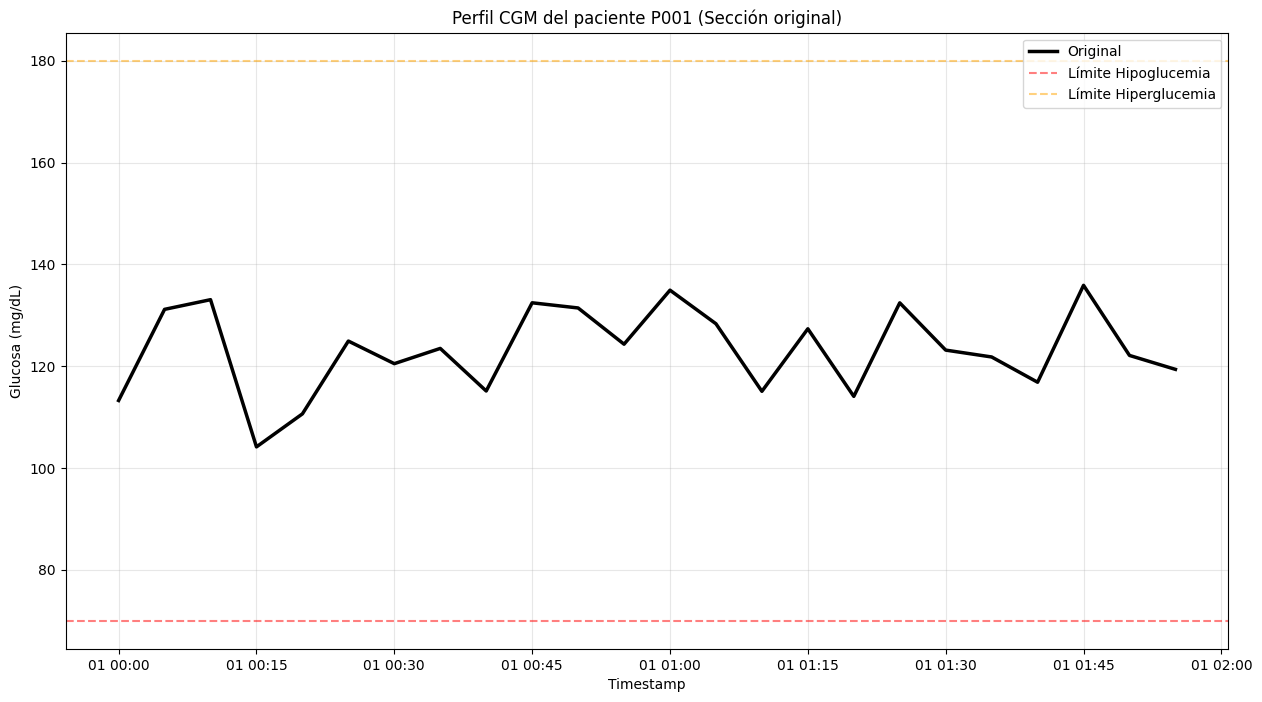

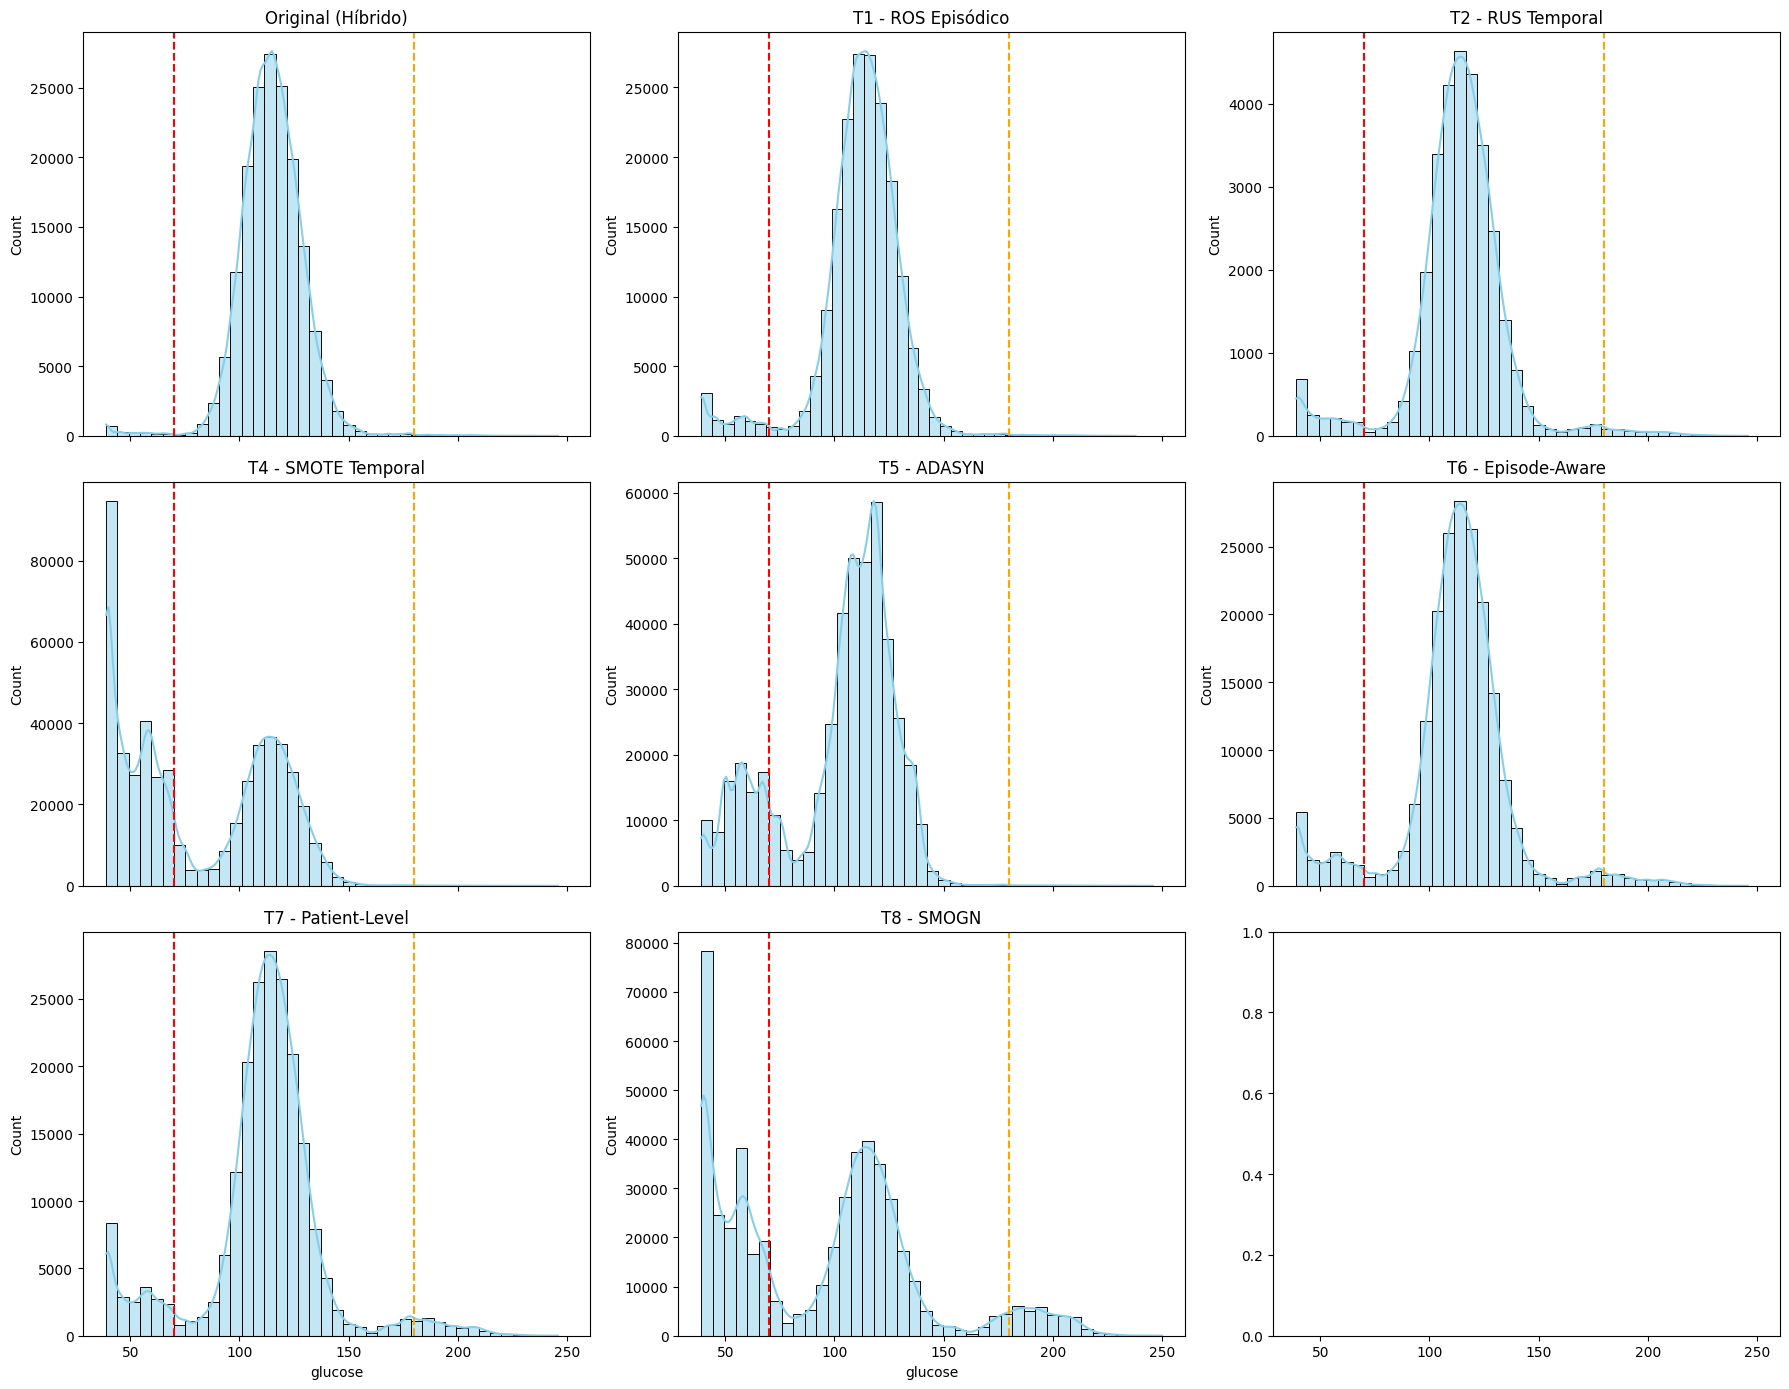

In [12]:
# Seleccionamos un paciente para visualizar un fragmento de su serie temporal
patient_to_plot = 'P001'

plt.figure(figsize=(15, 8))
orig_p = hybrid_df[hybrid_df['patient_id'] == patient_to_plot].sort_values('timestamp').head(120)
plt.plot(orig_p['timestamp'], orig_p['glucose'], label='Original', color='black', linewidth=2.5)

# Graficar ADASYN (que añade muestras sintéticas continuas desconectadas al final de la serie temporal)
# Para comparar, podemos mostrar la distribución de los valores de glucosa generados sintéticamente por cada técnica
plt.axhline(70, color='red', linestyle='--', alpha=0.5, label='Límite Hipoglucemia')
plt.axhline(180, color='orange', linestyle='--', alpha=0.5, label='Límite Hiperglucemia')
plt.title(f'Perfil CGM del paciente {patient_to_plot} (Sección original)')
plt.ylabel('Glucosa (mg/dL)')
plt.xlabel('Timestamp')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Distribución de los valores de glucosa en el dataset resultante
fig, axes = plt.subplots(3, 3, figsize=(18, 14), sharex=True)
axes = axes.flatten()
for i, (name, df) in enumerate(datasets.items()):
    sns.histplot(df['glucose'], bins=40, ax=axes[i], kde=True, color='skyblue')
    axes[i].set_title(name)
    axes[i].axvline(70, color='red', linestyle='--')
    axes[i].axvline(180, color='orange', linestyle='--')

plt.tight_layout()
plt.show()


## Conclusiones Clínicas y Recomendaciones Metodológicas

### Resumen de Hallazgos
1. **Técnicas Clínicamente Seguras**: 
   - **T3 (Cost-Sensitive Learning)** es la única técnica 100% segura que no genera ningún tipo de artefacto fisiológico.
   - **T6 (Episode-Aware Resampling)** es la mejor opción generativa para series temporales porque mantiene intacta la secuencia completa del episodio.
   - **T7 (Patient-Level Strategy)** es fundamental debido a la alta heterogeneidad inter-paciente.
2. **Técnicas de Alto Riesgo Clínico**:
   - **T5 (ADASYN)** y **SMOTE Clásico** (no restringido) producen distorsiones masivas en la tasa de cambio y destruyen la autocorrelación lag-1 al interpolar muestras independientes en el espacio de características.
   - **T4 (SMOTE Temporal)** e **T8 (SMOGN)** son seguras si se acotan de forma estricta a nivel del mismo paciente y dentro de ventanas temporales acotadas.

### Conclusión Metodológica para el TFM
Para construir un pipeline predictivo robusto de glucosa:
- Usar **T3 (Cost-Sensitive)** como baseline principal.
- Si se requiere data augmentation, emplear **T6 (Episode-Aware)** combinado con **T7 (Patient-Level)**.
- Descartar por completo ADASYN y SMOTE no adaptados en series CGM.